# AFDM 仿射频分复用：调制 / 解调仿真笔记

> 论文精读 + 可视化仿真：**H. S. Rou, V. Savaux, Z. Sui, G. T. F. de Abreu, Z. Liu,
> "AFDM: Evolving OFDM Towards 6G+", IEEE Open Journal of the Communications Society.**

**AFDM（Affine Frequency Division Multiplexing，仿射频分复用）** 是面向 6G 的演进型波形。
它把 OFDM 的「正弦子载波」换成 **chirp（线性调频）子载波**，从而在
**双弥散（doubly-dispersive）信道**——即同时存在 **多径时延（delay）** 与 **多普勒（Doppler）**
的高速移动场景——下保持子载波正交性并获得 **全分集**，而硬件上几乎完全复用 OFDM 收发链
（只多了两次 chirp 相位旋转）。

本笔记的目标：**把 AFDM 的调制 / 解调全过程「拆开」并逐级可视化**，并用仿真验证它在
带时延、多普勒的信道下相对 OFDM 的优势。

**约定的系统参数（5G NR 风格）：**

| 参数 | 取值 |
|---|---|
| 带宽 | 100 MHz |
| 子载波间隔 SCS | 30 kHz |
| FFT 大小 $N$ | 4096 |
| 活跃子载波 | 273 RB × 12 = 3276 |
| 采样率 $f_s = N\cdot\text{SCS}$ | 122.88 MHz |
| 数据调制 | **16QAM** |
| 参考信号 DMRS | **QPSK** |

> 📦 **代码分层**：与「调制 / 解调」无直接关系的底层实现——双弥散信道、QAM/QPSK 映射、
> DMRS、噪声、均衡器——都放在同目录的 [`afdm_channel.py`](./afdm_channel.py) 中。
> 本 Notebook 只保留 **AFDM 调制 / 解调核心代码（DAFT/IDAFT 与收发链）**，以保持聚焦。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append(os.path.abspath('.'))            # make afdm_channel.py importable
from afdm_channel import *                        # channel / mappers / DMRS / equalizers

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
np.random.seed(2024)

nr = nr_numerology()
print('--- 5G NR-like numerology ---')
for k, v in nr.items():
    print(f'{k:>6s} = {v}')

--- 5G NR-like numerology ---
   scs = 30000.0
    bw = 100000000.0
 N_fft = 4096
  N_rb = 273
  N_sc = 3276
    fs = 122880000.0
    Ts = 8.138020833333334e-09
    fc = 4000000000.0


---
## 1. 双弥散信道：时延 + 多普勒

无线高速移动信道的连续时变冲激响应（TVIRF）由 $P$ 条可分辨径叠加而成（论文式 (1)）：

$$h(t,\tau)=\sum_{p=1}^{P} h_p\, e^{j2\pi\nu_p t}\,\delta(\tau-\tau_p)$$

- $\tau_p$：第 $p$ 径的**时延**（频率选择性）；
- $\nu_p$：第 $p$ 径的**多普勒频移**（时间选择性）；
- 二者同时存在 → **双弥散（doubly-dispersive）** 衰落。

采样后（$T_s=1/f_s$），离散输入输出关系为（式 (5)）：

$$r[n]=\sum_{p=1}^{P} h_p\, e^{j2\pi f_p \frac{n}{N}}\, s[n-\ell_p]+w[n]$$

其中两个**归一化**量是后续一切分析的关键（式 (4)）：

$$\underbrace{\ell_p=\frac{\tau_p}{T_s}}_{\text{归一化时延}}\qquad
  \underbrace{f_p=N\nu_p T_s=\frac{\nu_p}{\text{SCS}}}_{\text{数字多普勒}}$$

根据 $\ell_p,f_p$ 取整数还是分数，分三种情形：**IDID**（整数时延整数多普勒）、
**IDFD**（整数时延分数多普勒）、**FDFD**（分数时延分数多普勒，最贴近真实 6G 信道）。

In [2]:
# Build a high-mobility doubly-dispersive channel for the NR walkthrough.
# (carrier 28 GHz, v = 350 km/h -> Doppler is a visible fraction of the SCS)
N = nr['N_fft']
ch = gen_doubly_dispersive_channel(N, nr['fs'], fc=28e9, velocity_kmh=350, seed=7)

print(f"max Doppler nu_max = {ch['nu_max']:.0f} Hz   "
      f"(= {ch['nu_max']/nr['scs']*100:.1f}% of SCS)\n")
print(f"{'path':>4} {'|h|':>7} {'delay[ns]':>10} {'l_p(norm)':>10} "
      f"{'Doppler[Hz]':>12} {'f_p(norm)':>10}")
for p in range(ch['P']):
    print(f"{p:>4} {abs(ch['h'][p]):>7.3f} {ch['tau'][p]*1e9:>10.1f} "
          f"{ch['ell'][p]:>10.2f} {ch['nu'][p]:>12.0f} {ch['fdop'][p]:>10.3f}")

max Doppler nu_max = 9074 Hz   (= 30.2% of SCS)

path     |h|  delay[ns]  l_p(norm)  Doppler[Hz]  f_p(norm)
   0   0.509        0.0       0.00         9069      0.302
   1   0.428       30.0       3.69         3927      0.131
   2   0.433       70.0       8.60         2645      0.088
   3   0.336       90.0      11.06        -8891     -0.296
   4   0.475      110.0      13.52        -2968     -0.099
   5   0.178      190.0      23.35        -1612     -0.054


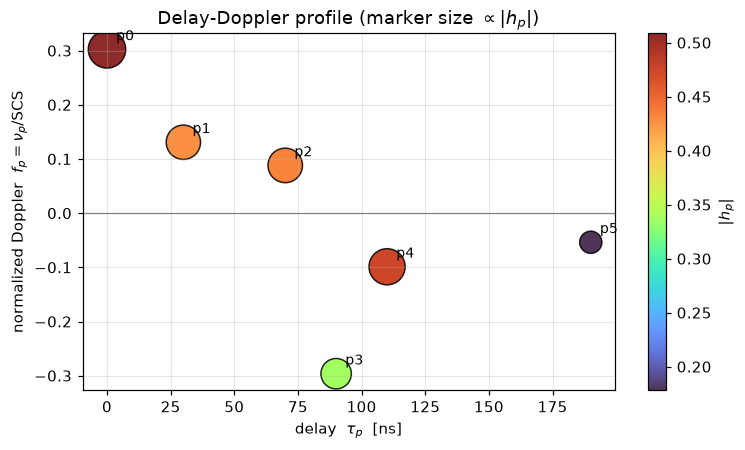

In [3]:
# Visualization (1): delay-Doppler profile of the channel
fig, ax = plt.subplots(figsize=(7, 4.2))
sz = 600 * np.abs(ch['h']) / np.abs(ch['h']).max()
sc = ax.scatter(ch['tau'] * 1e9, ch['fdop'], s=sz, c=np.abs(ch['h']),
                cmap='turbo', edgecolors='k', alpha=0.85)
for p in range(ch['P']):
    ax.annotate(f'p{p}', (ch['tau'][p]*1e9, ch['fdop'][p]),
                textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('delay  $\\tau_p$  [ns]')
ax.set_ylabel('normalized Doppler  $f_p = \\nu_p/\\mathrm{SCS}$')
ax.set_title('Delay-Doppler profile (marker size $\\propto |h_p|$)')
fig.colorbar(sc, label='$|h_p|$')
plt.tight_layout(); plt.show()

### 1.1 分数时延与脉冲整形核 $g(\cdot)$

当 $\ell_p$ 非整数时，$s[n-\ell_p]$ 不能简单移位，而要通过插值核重建（式 (6)）：

$$s[n-\ell_p]=\sum_{m=0}^{N-1}s[m]\,g\big((n-m)-\ell_p\big)$$

核 $g(\cdot)$ 来自实际发射脉冲 $p(t)$：**sinc**（理想带限）、**升余弦**、或 **矩形**（无整形）。
核的选择决定了单径信道矩阵 $\mathbf H_p$ 的「样本间耦合」稠密程度（复现论文 Fig. 2）。

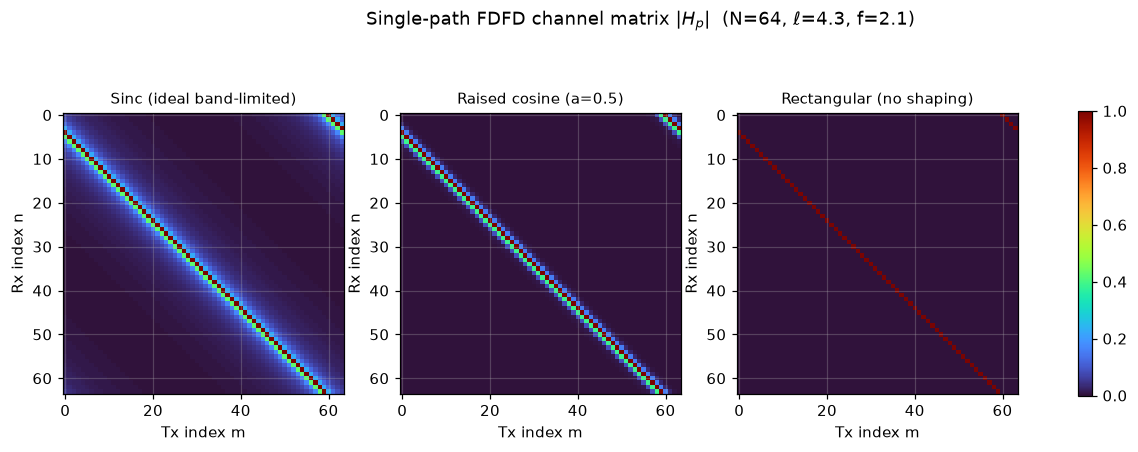

In [4]:
# Visualization (2): impact of the pulse-shaping kernel on a single-path matrix
# (small N for display; fractional delay l=4.3, fractional Doppler f=2.1, as in the paper)
Nv = 64
kernels = [('Sinc (ideal band-limited)', 'sinc'),
           ('Raised cosine (a=0.5)', 'rc'),
           ('Rectangular (no shaping)', 'rect')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, ker) in zip(axes, kernels):
    Hp = per_path_matrix(1.0, 4.3, 2.1, Nv, ker)
    im = ax.imshow(np.abs(Hp), cmap='turbo', aspect='equal')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Tx index m'); ax.set_ylabel('Rx index n')
fig.suptitle('Single-path FDFD channel matrix $|H_p|$  (N=64, $\\ell$=4.3, f=2.1)', y=1.02)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

---
## 2. AFDM 调制核心：DAFT / IDAFT

AFDM 把数据符号 $\mathbf x$ 放在 **离散仿射傅里叶变换（DAFT）** 域。前向 DAFT 矩阵为（式 (31)）：

$$\boxed{\;\mathbf A=\boldsymbol\Lambda_{\lambda_2}\,\mathbf F_N\,\boldsymbol\Lambda_{\lambda_1}\;}
\qquad
\boldsymbol\Lambda_{\lambda_i}=\mathrm{diag}\!\big(e^{-j2\pi\lambda_i n^2}\big)_{n=0}^{N-1}$$

其中 $\mathbf F_N$ 是归一化 DFT 矩阵，$\boldsymbol\Lambda_{\lambda_i}$ 是 **chirp（二次相位）对角阵**。

- $\lambda_1=\lambda_2=0$ ⟹ 退化为 **DFT（即 OFDM）**；
- $\lambda_1=\lambda_2=\tfrac1{2N}$ ⟹ 离散 Fresnel 变换（OCDM）。

**调制（IDAFT）**：$\;\mathbf s=\mathbf A^{H}\mathbf x\;$（式 (30)）；　**解调（DAFT）**：$\;\mathbf y=\mathbf A\,\mathbf r$。

两个 chirp 参数的物理意义：

- $c_1\equiv\lambda_1$ 决定**抗多普勒/全分集**能力，需满足
  $\;c_1\ge\dfrac{2(\lfloor f_\max\rceil+\xi)+1}{2N}\;$（式 (32)，$\xi$ 为多普勒保护带）；
- $c_2\equiv\lambda_2$ 不影响正交性，仅调节波形性质（PAPR、模糊函数），通常取 $c_2=\tfrac1{2N}$。

> 这正是 AFDM 与 OFDM 的**唯一结构差异**：在 IFFT/FFT 前后各插入一次 chirp 相位旋转。

In [5]:
# ---- AFDM modulation/demodulation core (kept in the notebook on purpose) ----
def chirp_diag(c, N):
    '''Chirp phase vector exp(-j 2 pi c n^2), the diagonal of Lambda_c (eq. 31).'''
    n = np.arange(N)
    return np.exp(-1j * 2 * np.pi * c * (n ** 2))

def dft_matrix(N):
    '''Normalized N-point DFT matrix F (unitary).'''
    k = np.arange(N)
    return np.exp(-2j * np.pi * np.outer(k, k) / N) / np.sqrt(N)

def daft_matrix(N, c1, c2):
    '''Forward DAFT matrix  A = Lambda_c2 @ F @ Lambda_c1  (eq. 31).'''
    return (chirp_diag(c2, N)[:, None] * dft_matrix(N)) * chirp_diag(c1, N)[None, :]

def afdm_mod(x, c1, c2):
    '''IDAFT modulation  s = A^H x  (eq. 30), implemented with the IFFT.

    A^H = Lambda_c1^H . F^H . Lambda_c2^H, applied right-to-left:
      pre-IFFT chirp (c2)  ->  IFFT  ->  post-IFFT chirp (c1).
    '''
    N = len(x); n = np.arange(N)
    x_pre = np.exp(+1j * 2 * np.pi * c2 * n ** 2) * x      # Lambda_c2^H  (pre-IFFT)
    u = np.sqrt(N) * np.fft.ifft(x_pre)                    # F^H  (IFFT)
    s = np.exp(+1j * 2 * np.pi * c1 * n ** 2) * u          # Lambda_c1^H (post-IFFT)
    return s

def afdm_demod(r, c1, c2):
    '''Forward DAFT demodulation  y = A r, implemented with the FFT.'''
    N = len(r); n = np.arange(N)
    a = np.exp(-1j * 2 * np.pi * c1 * n ** 2) * r          # Lambda_c1 (pre-FFT)
    b = np.fft.fft(a) / np.sqrt(N)                         # F (FFT)
    y = np.exp(-1j * 2 * np.pi * c2 * n ** 2) * b          # Lambda_c2 (post-FFT)
    return y

# Sanity check: FFT-based mod == matrix A^H x, and demod is its exact inverse.
_N = 64; _c1, _c2 = 7/(2*_N), 1/(2*_N)
_x = np.random.randn(_N) + 1j*np.random.randn(_N)
_A = daft_matrix(_N, _c1, _c2)
assert np.allclose(afdm_mod(_x, _c1, _c2), _A.conj().T @ _x), 'IDAFT mismatch'
assert np.allclose(afdm_demod(afdm_mod(_x, _c1, _c2), _c1, _c2), _x), 'A not unitary'
print('AFDM core OK:  s = A^H x   and   A A^H = I   verified.')

AFDM core OK:  s = A^H x   and   A A^H = I   verified.


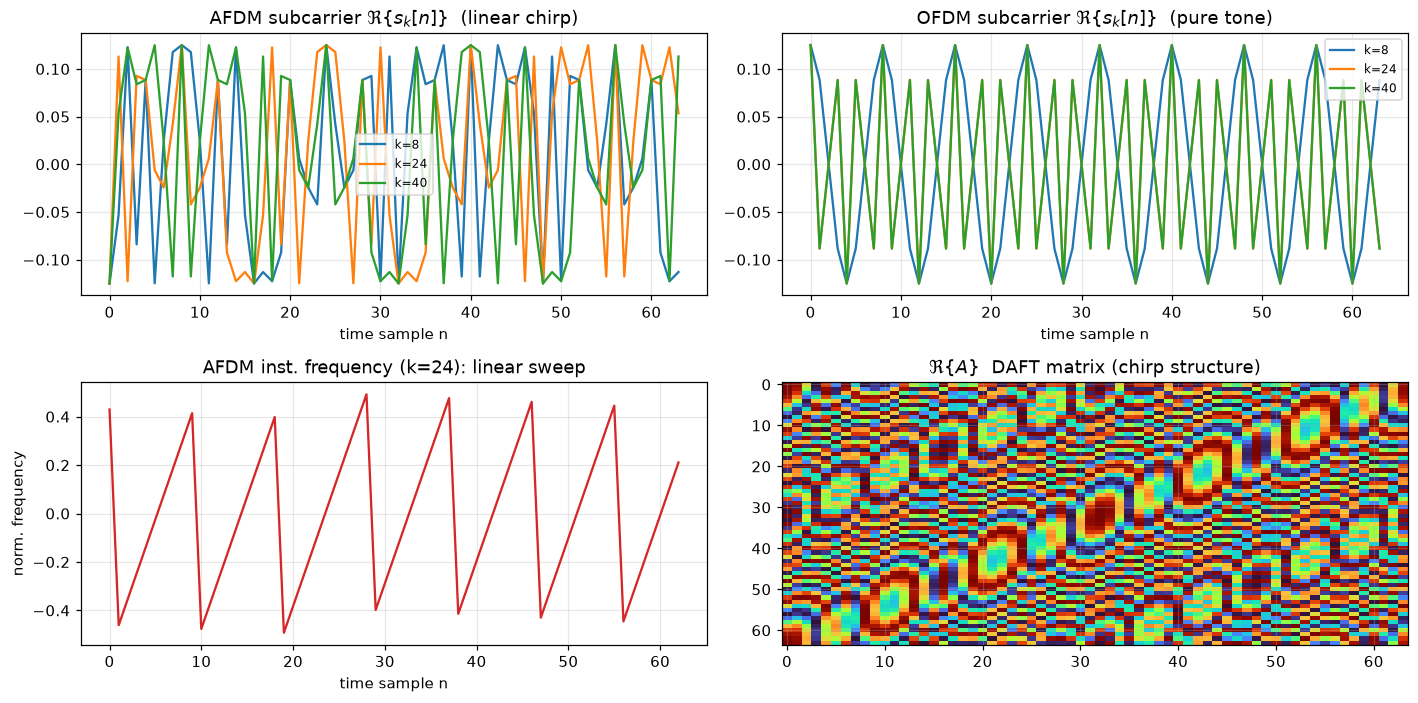

In [6]:
# Visualization (3): chirp subcarriers (AFDM) vs sinusoidal subcarriers (OFDM)
Nv = 64
c1, c2 = 7/(2*Nv), 1/(2*Nv)
ks = [8, 24, 40]                         # a few affine-frequency indices
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5))

for k in ks:
    e = np.zeros(Nv, complex); e[k] = 1
    s_afdm = afdm_mod(e, c1, c2)         # AFDM basis (chirp)
    s_ofdm = afdm_mod(e, 0.0, 0.0)       # OFDM basis (pure sinusoid)
    axes[0, 0].plot(np.real(s_afdm), label=f'k={k}')
    axes[0, 1].plot(np.real(s_ofdm), label=f'k={k}')
axes[0, 0].set_title('AFDM subcarrier $\\Re\\{s_k[n]\\}$  (linear chirp)')
axes[0, 1].set_title('OFDM subcarrier $\\Re\\{s_k[n]\\}$  (pure tone)')
for ax in axes[0]:
    ax.set_xlabel('time sample n'); ax.legend(fontsize=8)

# Instantaneous frequency: chirp sweeps linearly, OFDM stays constant
inst = lambda s: np.diff(np.unwrap(np.angle(s))) / (2*np.pi)
e = np.zeros(Nv, complex); e[24] = 1
axes[1, 0].plot(inst(afdm_mod(e, c1, c2)), 'C3')
axes[1, 0].set_title('AFDM inst. frequency (k=24): linear sweep')
axes[1, 1].imshow(np.real(daft_matrix(Nv, c1, c2)), cmap='turbo', aspect='auto')
axes[1, 1].set_title('$\\Re\\{A\\}$  DAFT matrix (chirp structure)')
for ax in axes[1, :1]:
    ax.set_xlabel('time sample n'); ax.set_ylabel('norm. frequency')
plt.tight_layout(); plt.show()

---
## 3. 调制过程逐级可视化（NR 全规模 $N=4096$）

完整发射链（论文 Fig. 4b）：

$$\text{bits}\;\to\;\underbrace{\text{16QAM 数据 + QPSK DMRS}}_{\text{资源映射}}\;\to\;
\underbrace{\Lambda_{c_2}}_{\text{IFFT 前 chirp}}\;\to\;\text{IFFT}\;\to\;
\underbrace{\Lambda_{c_1}}_{\text{IFFT 后 chirp}}\;\to\;\underbrace{\text{CPP 前缀}}_{\text{chirp 周期前缀}}$$

我们把每一级的中间信号都画出来。

In [7]:
# --- chirp parameters from the channel's max Doppler (eq. 32) ---
N = nr['N_fft']
fmax = int(np.ceil(np.max(np.abs(ch['fdop'])))); xi = 1
c1 = (2 * (fmax + xi) + 1) / (2 * N)     # >= full-diversity bound
c2 = 1 / (2 * N)
print(f'fmax(rounded)={fmax}, guard xi={xi}  ->  c1={c1:.6f}, c2={c2:.6f}')

# --- resource mapping: contiguous active band, comb-6 QPSK DMRS, rest 16QAM ---
N_sc = nr['N_sc']
active = np.arange(N//2 - N_sc//2, N//2 + N_sc//2)   # centered active subcarriers
dmrs_idx = active[::6]                                # comb-type DMRS positions
data_idx = np.setdiff1d(active, dmrs_idx)

bits = np.random.randint(0, 2, 4 * len(data_idx))    # 4 bits / 16QAM symbol
data_sym = qam16_map(bits)
dmrs_sym = gen_dmrs(dmrs_idx)                         # QPSK reference symbols

x = np.zeros(N, dtype=complex)                        # affine-frequency-domain block
x[data_idx] = data_sym
x[dmrs_idx] = dmrs_sym

# --- AFDM modulation, stage by stage ---
n = np.arange(N)
stage_pre = np.exp(+1j * 2 * np.pi * c2 * n**2) * x  # (1) pre-IFFT chirp
stage_ifft = np.sqrt(N) * np.fft.ifft(stage_pre)     # (2) IFFT
s = np.exp(+1j * 2 * np.pi * c1 * n**2) * stage_ifft # (3) post-IFFT chirp  => s = A^H x
assert np.allclose(s, afdm_mod(x, c1, c2))

# --- CPP (chirp-periodic prefix), phi_cp(n) = c1 (N^2 + 2 N n)  (eq. 8) ---
Ncp = 288
ncp = np.arange(-Ncp, 0)
phi_cp = c1 * (N**2 + 2 * N * ncp)
cpp = s[N + ncp] * np.exp(1j * 2 * np.pi * phi_cp)
s_tx = np.concatenate([cpp, s])
print(f'data symbols={len(data_idx)}, DMRS symbols={len(dmrs_idx)}, '
      f'CPP length={Ncp}, Tx block={len(s_tx)} samples')

fmax(rounded)=1, guard xi=1  ->  c1=0.000610, c2=0.000122
data symbols=2730, DMRS symbols=546, CPP length=288, Tx block=4384 samples


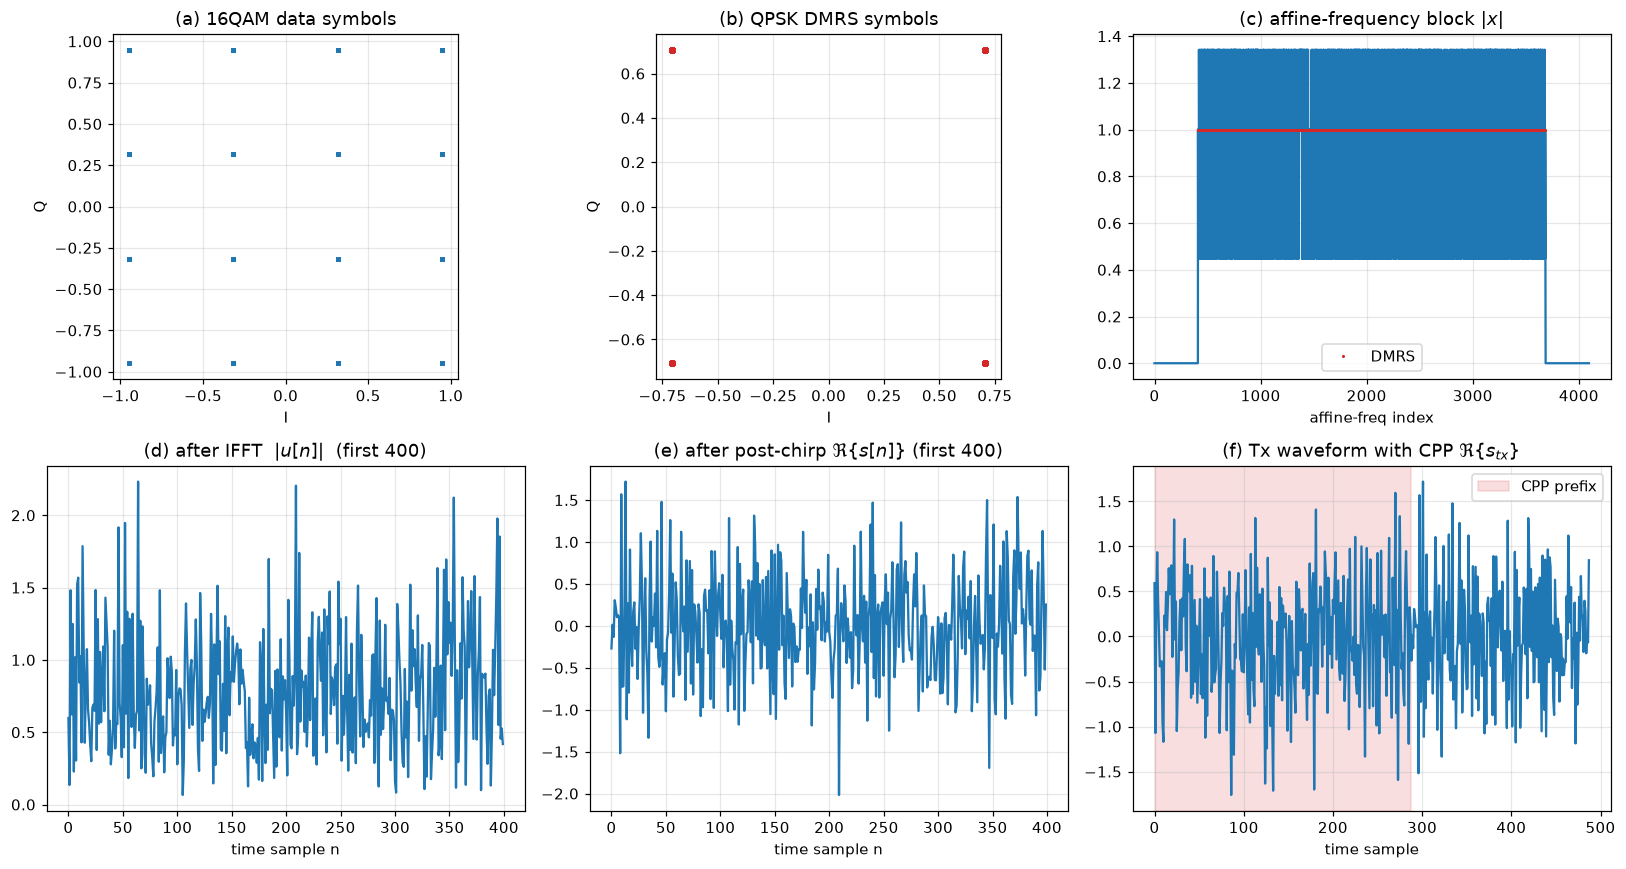

In [8]:
# Visualization (4): the modulation chain, stage by stage
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].scatter(data_sym.real, data_sym.imag, s=4, alpha=0.3)
axes[0,0].set_title('(a) 16QAM data symbols'); axes[0,0].set_aspect('equal')
axes[0,0].set_xlabel('I'); axes[0,0].set_ylabel('Q')

axes[0,1].scatter(dmrs_sym.real, dmrs_sym.imag, s=10, c='C3')
axes[0,1].set_title('(b) QPSK DMRS symbols'); axes[0,1].set_aspect('equal')
axes[0,1].set_xlabel('I'); axes[0,1].set_ylabel('Q')

axes[0,2].plot(np.abs(x))
axes[0,2].plot(dmrs_idx, np.abs(x[dmrs_idx]), '.', c='C3', ms=2, label='DMRS')
axes[0,2].set_title('(c) affine-frequency block $|x|$'); axes[0,2].legend()
axes[0,2].set_xlabel('affine-freq index')

axes[1,0].plot(np.abs(stage_ifft)[:400])
axes[1,0].set_title('(d) after IFFT  $|u[n]|$  (first 400)')
axes[1,0].set_xlabel('time sample n')

axes[1,1].plot(np.real(s)[:400])
axes[1,1].set_title('(e) after post-chirp $\\Re\\{s[n]\\}$ (first 400)')
axes[1,1].set_xlabel('time sample n')

axes[1,2].plot(np.real(s_tx)[:Ncp+200])
axes[1,2].axvspan(0, Ncp, color='C3', alpha=0.15, label='CPP prefix')
axes[1,2].set_title('(f) Tx waveform with CPP $\\Re\\{s_{tx}\\}$')
axes[1,2].legend(); axes[1,2].set_xlabel('time sample')
plt.tight_layout(); plt.show()

---
## 4. 通过双弥散信道

发射波形经过第 1 节的信道：循环卷积 + 多普勒相位 + AWGN。由于使用了 CPP，去前缀后的
输入输出关系等价于循环模型 $\mathbf r=\mathbf H\mathbf s+\mathbf w$（论文式 (9)），
这正是 `afdm_channel.apply_channel()` 的时域高效实现。

SNR = 25 dB,  received block = 4096 samples


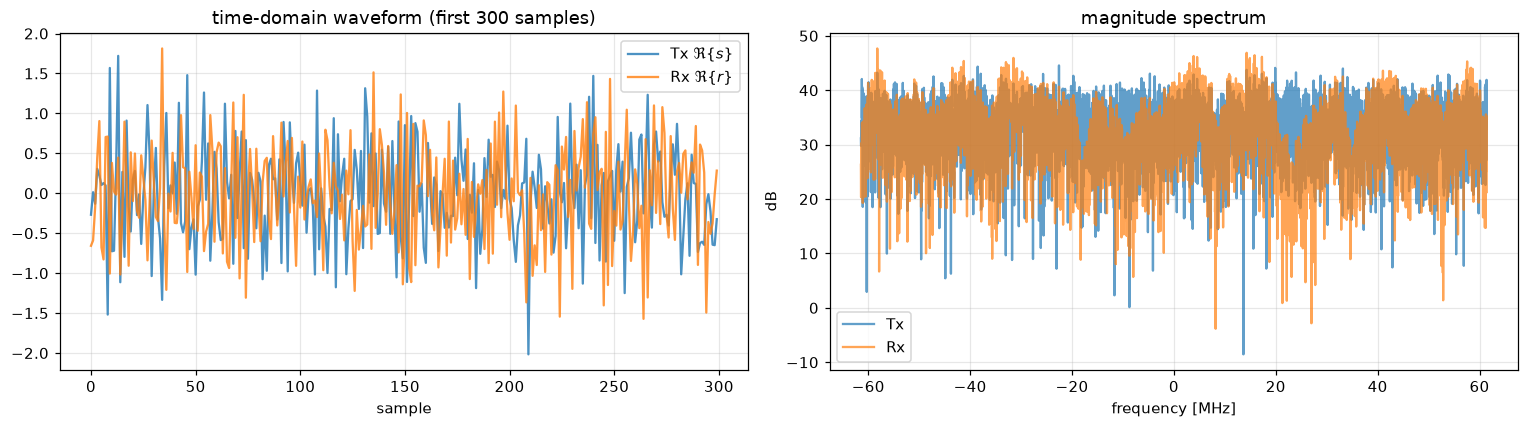

In [9]:
# Pass through the channel (circular model after CP removal) and add AWGN.
snr_db = 25
r_clean = apply_channel(s, ch, N, kernel='sinc')
sigp = np.mean(np.abs(r_clean) ** 2)
r, n0 = awgn(r_clean, snr_db, sig_power=sigp)
print(f'SNR = {snr_db} dB,  received block = {len(r)} samples')

# Visualization (5): Tx vs Rx waveform and spectrum
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.real(s)[:300], label='Tx $\\Re\\{s\\}$', alpha=0.8)
axes[0].plot(np.real(r)[:300], label='Rx $\\Re\\{r\\}$', alpha=0.8)
axes[0].set_title('time-domain waveform (first 300 samples)')
axes[0].set_xlabel('sample'); axes[0].legend()

Ssp = 20*np.log10(np.abs(np.fft.fftshift(np.fft.fft(s))) + 1e-9)
Rsp = 20*np.log10(np.abs(np.fft.fftshift(np.fft.fft(r))) + 1e-9)
fb = (np.arange(N) - N//2) * nr['scs'] / 1e6
axes[1].plot(fb, Ssp, label='Tx', alpha=0.7)
axes[1].plot(fb, Rsp, label='Rx', alpha=0.7)
axes[1].set_title('magnitude spectrum'); axes[1].set_xlabel('frequency [MHz]')
axes[1].set_ylabel('dB'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 5. 解调过程逐级可视化

接收链是发射链的镜像（论文 Fig. 4b）：去前缀 $\to\Lambda_{c_1}\to$ FFT $\to\Lambda_{c_2}$，
即 $\mathbf y=\mathbf A\,\mathbf r$。

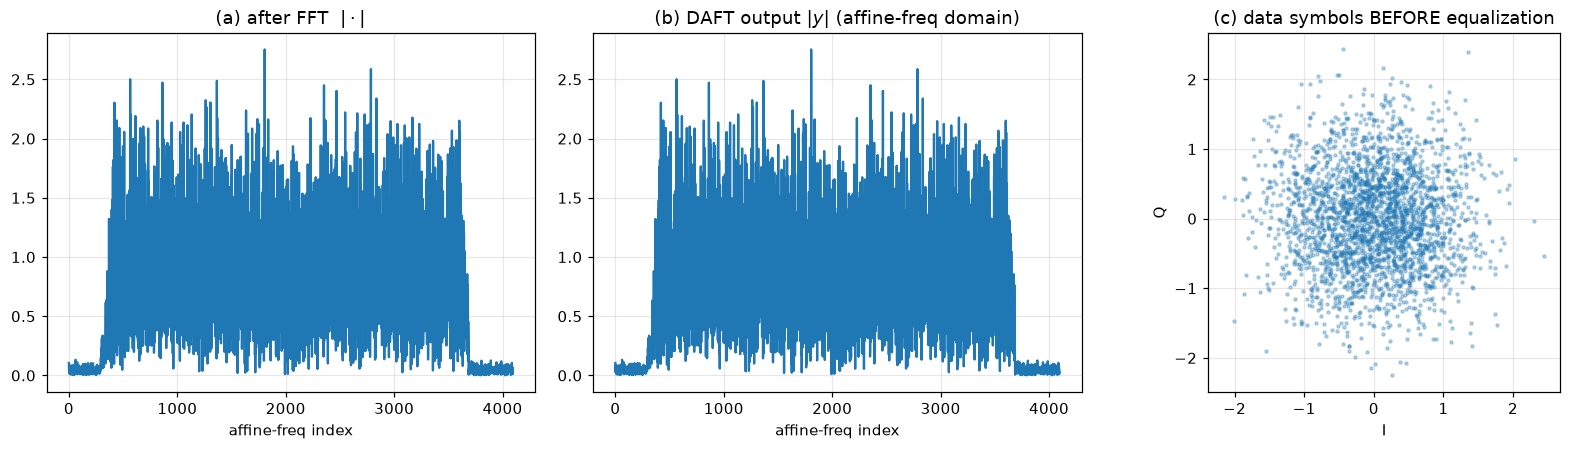

At low Doppler the affine-freq symbols are already close to 16QAM; residual rotation/spread is removed by equalization next.


In [10]:
# AFDM demodulation, stage by stage
stage_prefft = np.exp(-1j * 2 * np.pi * c1 * n**2) * r   # (1) pre-FFT chirp
stage_fft = np.fft.fft(stage_prefft) / np.sqrt(N)        # (2) FFT
y = np.exp(-1j * 2 * np.pi * c2 * n**2) * stage_fft      # (3) post-FFT chirp => y = A r
assert np.allclose(y, afdm_demod(r, c1, c2))

# Visualization (6): demod stages + pre-equalization constellation
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(np.abs(stage_fft))
axes[0].set_title('(a) after FFT  $|\\cdot|$'); axes[0].set_xlabel('affine-freq index')

axes[1].plot(np.abs(y))
axes[1].set_title('(b) DAFT output $|y|$ (affine-freq domain)')
axes[1].set_xlabel('affine-freq index')

axes[2].scatter(y[data_idx].real, y[data_idx].imag, s=4, alpha=0.3)
axes[2].set_title('(c) data symbols BEFORE equalization')
axes[2].set_aspect('equal'); axes[2].set_xlabel('I'); axes[2].set_ylabel('Q')
plt.tight_layout(); plt.show()
print('At low Doppler the affine-freq symbols are already close to 16QAM; '
      'residual rotation/spread is removed by equalization next.')

---
## 6. 有效信道矩阵：OFDM vs AFDM（复现论文 Fig. 3）

把调制解调并入信道，得到符号域**有效信道矩阵**：

$$\boldsymbol\Xi_{\text{OFDM}}=\mathbf F\,\mathbf H\,\mathbf F^{H},\qquad
  \boldsymbol\Xi_{\text{AFDM}}=\mathbf A\,\mathbf H\,\mathbf A^{H}$$

下面用论文 Fig. 3 的 3 径参数（$N=64$，$\ell=\{1.3,3.25,5.96\}$，$f=\{1.1,-2.3,0.85\}$）对比。
**关键结论**：有多普勒时 OFDM 子载波正交性被破坏 → $\boldsymbol\Xi$ 严重弥散（强 ICI，各径不可分辨）；
AFDM 则把能量**集中**在少数对角带上，保持可分辨 / 近稀疏结构，便于均衡与检测。

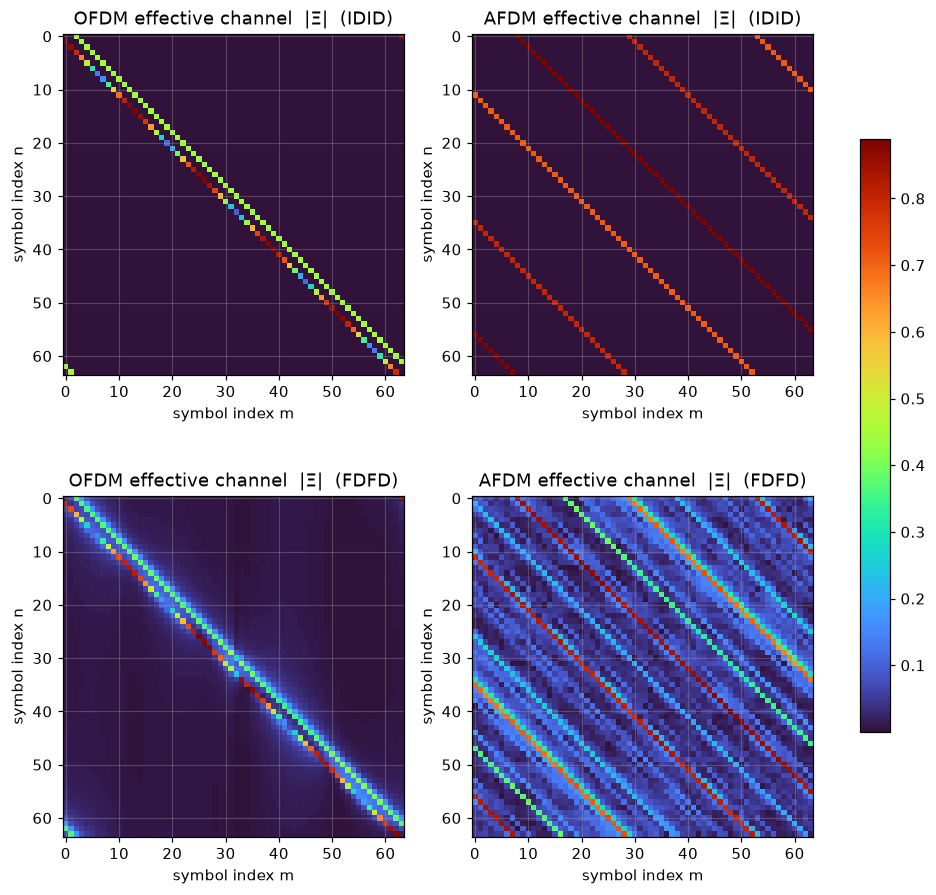

In [11]:
Nv = 64
paths_int  = make_paths([1, 0.9, 0.8], [1, 3, 6],          [1, -2, 1])      # IDID (rounded)
paths_frac = make_paths([1, 0.9, 0.8], [1.3, 3.25, 5.96],  [1.1, -2.3, 0.85])  # FDFD
fmaxp = 3; xip = 1
c1p, c2p = (2*(fmaxp+xip)+1)/(2*Nv), 1/(2*Nv)
F = dft_matrix(Nv); A = daft_matrix(Nv, c1p, c2p)

def eff(Hmat, M): return M @ Hmat @ M.conj().T

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row, (name, pth) in enumerate([('IDID', paths_int), ('FDFD', paths_frac)]):
    H = build_channel_matrix(pth, Nv, 'sinc')
    for col, (sys, M) in enumerate([('OFDM', F), ('AFDM', A)]):
        Xi = eff(H, M)
        im = axes[row, col].imshow(np.abs(Xi), cmap='turbo', aspect='equal')
        axes[row, col].set_title(f'{sys} effective channel  $|\\Xi|$  ({name})')
        axes[row, col].set_xlabel('symbol index m'); axes[row, col].set_ylabel('symbol index n')
fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()

---
## 7. DMRS 信道估计、均衡与检测

接收端用 **QPSK DMRS** 估计信道，再做均衡 + 16QAM 判决。这里在中等规模 $N=512$、
显著多普勒的信道上对比两种均衡：

1. **DMRS 一抽头（对角）均衡**：$\hat x_k=y_k/\hat g_k$，简单但忽略了 $\boldsymbol\Xi$ 的带状耦合；
2. **LMMSE 均衡**：$\hat{\mathbf x}=(\boldsymbol\Xi^{H}\boldsymbol\Xi+\sigma^2\mathbf I)^{-1}\boldsymbol\Xi^{H}\mathbf y$，
   利用 AFDM 稀疏 $\boldsymbol\Xi$ 抑制残余 ICI。

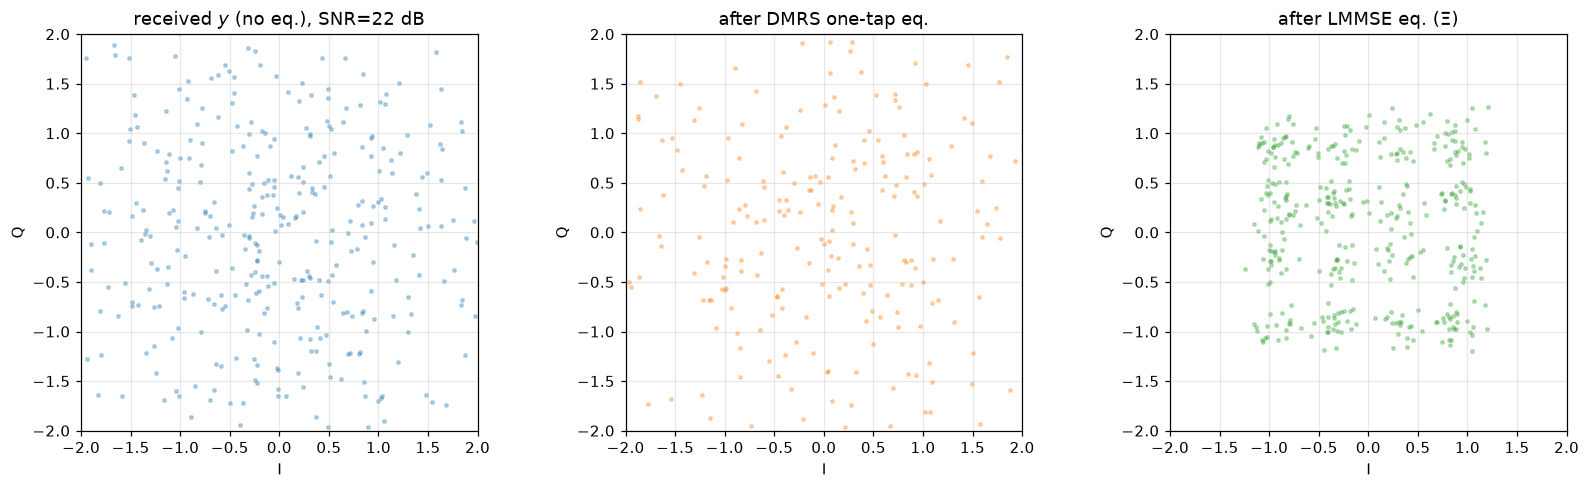

 one-tap equalizer raw BER = 4.525e-01
   LMMSE equalizer raw BER = 7.812e-03


In [12]:
Ne = 512
fmax_e = 1; xi_e = 1
c1e, c2e = (2*(fmax_e+xi_e)+1)/(2*Ne), 1/(2*Ne)
Ae = daft_matrix(Ne, c1e, c2e)

# A high-mobility fractional channel (meaningful normalized Doppler)
pth_e = make_paths([1.0, 0.8*np.exp(1j*1.1), 0.6*np.exp(-1j*0.7), 0.5*np.exp(1j*2.0)],
                   [0, 2.3, 5.7, 9.1], [0.7, -0.9, 0.5, -0.6])
He = build_channel_matrix(pth_e, Ne, 'sinc')
Xi_e = Ae @ He @ Ae.conj().T

# Tx: 16QAM data + comb QPSK DMRS over the whole block
idx = np.arange(Ne)
dmrs_e = idx[::4]; data_e = np.setdiff1d(idx, dmrs_e)
b = np.random.randint(0, 2, 4*len(data_e))
xe = np.zeros(Ne, complex)
xe[data_e] = qam16_map(b)
xe[dmrs_e] = gen_dmrs(dmrs_e)

snr_e = 22
ye = Xi_e @ xe
ye, n0e = awgn(ye, snr_e, sig_power=np.mean(np.abs(ye)**2))

# (1) DMRS diagonal one-tap equalization
g_hat = estimate_channel_from_dmrs(ye, xe[dmrs_e], dmrs_e, Ne, smooth=15)
x_onetap = ye / g_hat
# (2) LMMSE using the structured effective channel
x_lmmse = lmmse_equalize(ye, Xi_e, n0e)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(ye[data_e].real, ye[data_e].imag, s=5, alpha=0.3)
axes[0].set_title(f'received $y$ (no eq.), SNR={snr_e} dB')
axes[1].scatter(x_onetap[data_e].real, x_onetap[data_e].imag, s=5, alpha=0.3, c='C1')
axes[1].set_title('after DMRS one-tap eq.')
axes[2].scatter(x_lmmse[data_e].real, x_lmmse[data_e].imag, s=5, alpha=0.3, c='C2')
axes[2].set_title('after LMMSE eq. ($\\Xi$)')
for ax in axes:
    ax.set_aspect('equal'); ax.set_xlabel('I'); ax.set_ylabel('Q')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
plt.tight_layout(); plt.show()

# bit error of the two equalizers
for name, xeq in [('one-tap', x_onetap), ('LMMSE', x_lmmse)]:
    be = np.mean(qam16_demap(xeq[data_e]) != b)
    print(f'{name:>8} equalizer raw BER = {be:.3e}')

---
## 8. 端到端 BER 仿真：AFDM vs OFDM

最后在同一双弥散信道（含分数时延、分数多普勒）下，用 Monte-Carlo 对比 AFDM 与 OFDM 的
**误比特率 (BER)**。两者使用相同的数据、相同的信道实现与噪声，均采用 LMMSE 均衡。
为便于对每次实现做 LMMSE，这里用较小的 $N=256$（NR 数值体系用于前面的调制/解调走查）。

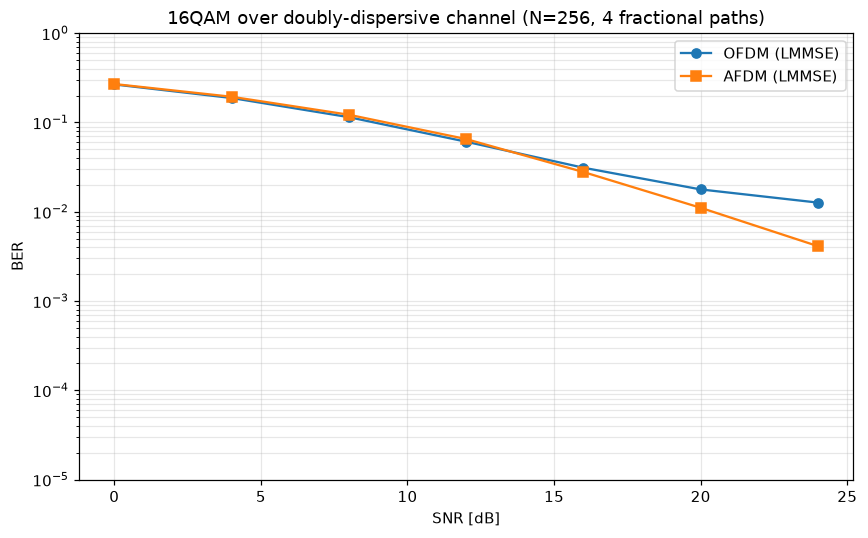

SNR(dB): [np.int64(0), np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20), np.int64(24)]
OFDM BER: [2.67e-01 1.88e-01 1.15e-01 6.09e-02 3.11e-02 1.78e-02 1.27e-02]
AFDM BER: [2.69e-01 1.94e-01 1.22e-01 6.52e-02 2.79e-02 1.11e-02 4.12e-03]


In [13]:
Nb = 256
fmax_b = 1; xi_b = 1
c1b, c2b = (2*(fmax_b+xi_b)+1)/(2*Nb), 1/(2*Nb)
Fb = dft_matrix(Nb); Ab = daft_matrix(Nb, c1b, c2b)

# Fixed fractional delay/Doppler grid; random Rayleigh gains per trial.
ell_b  = np.array([0.0, 2.4, 5.7, 9.3])
fdop_b = np.array([0.6, -0.8, 0.5, -0.7])
pdp    = 10 ** (np.array([0, -2, -4, -6]) / 20.0)
Pb = len(ell_b)

# Precompute per-path effective channels  Xi_p = M Hp M^H  (gain factored out).
Xi_ofdm_p, Xi_afdm_p = [], []
for lp, fp in zip(ell_b, fdop_b):
    Hp = per_path_matrix(1.0, lp, fp, Nb, 'sinc')
    Xi_ofdm_p.append(Fb @ Hp @ Fb.conj().T)
    Xi_afdm_p.append(Ab @ Hp @ Ab.conj().T)
Xi_ofdm_p = np.array(Xi_ofdm_p); Xi_afdm_p = np.array(Xi_afdm_p)

snr_list = np.arange(0, 25, 4)
n_trials = 250
rng = np.random.default_rng(1)
ber = {'OFDM': np.zeros(len(snr_list)), 'AFDM': np.zeros(len(snr_list))}
nbits_tot = np.zeros(len(snr_list))

for t in range(n_trials):
    g = pdp * (rng.standard_normal(Pb) + 1j*rng.standard_normal(Pb)) / np.sqrt(2)
    Xi_o = np.tensordot(g, Xi_ofdm_p, axes=1)
    Xi_a = np.tensordot(g, Xi_afdm_p, axes=1)
    bb = rng.integers(0, 2, 4*Nb)
    xb = qam16_map(bb)
    for si, snr in enumerate(snr_list):
        sigma2 = 1.0 / (10 ** (snr/10.0))
        w = np.sqrt(sigma2/2) * (rng.standard_normal(Nb) + 1j*rng.standard_normal(Nb))
        xo = lmmse_equalize(Xi_o @ xb + w, Xi_o, sigma2)
        xa = lmmse_equalize(Xi_a @ xb + w, Xi_a, sigma2)
        ber['OFDM'][si] += np.sum(qam16_demap(xo) != bb)
        ber['AFDM'][si] += np.sum(qam16_demap(xa) != bb)
        nbits_tot[si] += 4*Nb

for k in ber: ber[k] /= nbits_tot

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(snr_list, ber['OFDM'], 'o-', label='OFDM (LMMSE)')
ax.semilogy(snr_list, ber['AFDM'], 's-', label='AFDM (LMMSE)')
ax.set_xlabel('SNR [dB]'); ax.set_ylabel('BER'); ax.set_ylim(1e-5, 1)
ax.set_title(f'16QAM over doubly-dispersive channel (N={Nb}, {Pb} fractional paths)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

print('SNR(dB):', list(snr_list))
print('OFDM BER:', np.array2string(ber['OFDM'], formatter={'float': lambda v: f'{v:.2e}'}))
print('AFDM BER:', np.array2string(ber['AFDM'], formatter={'float': lambda v: f'{v:.2e}'}))

---
## 9. 小结

- **波形**：AFDM 用 chirp 子载波（DAFT 域）取代 OFDM 的正弦子载波，$\mathbf A=\Lambda_{c_2}\mathbf F\Lambda_{c_1}$。
- **调制 / 解调**：仅在 OFDM 的 IFFT/FFT 前后各加一次 chirp 相位旋转
  （$\mathbf s=\mathbf A^H\mathbf x$，$\mathbf y=\mathbf A\mathbf r$），加上 CPP 前缀，硬件几乎完全复用 OFDM。
- **抗双弥散**：在带时延 + 多普勒的信道中，OFDM 有效信道 $\Xi$ 严重弥散（ICI），
  AFDM 的 $\Xi$ 保持稀疏 / 可分辨（满足 $c_1\ge\frac{2(\lfloor f_\max\rceil+\xi)+1}{2N}$ 时获得全分集）。
- **仿真验证**：相同信道下 AFDM 的 BER 明显优于 OFDM。

| 维度 | OFDM | AFDM | OTFS |
|---|---|---|---|
| 子载波 | 正弦 | **chirp** | 延迟-多普勒网格 |
| 变换 | DFT | **DAFT（DFT + 2 次 chirp）** | ISFFT + Heisenberg / Zak |
| 硬件复用 OFDM | — | **几乎 100%** | 需全新结构 |
| 双弥散全分集 | 否 | **是** | 是 |
| 前缀 | CP | **CPP**（特定参数退化为 CP） | 双重 CP |

> AFDM 以「最小改动 OFDM」的代价获得 OTFS 级别的高移动性鲁棒性，是 6G+ 演进波形的有力候选。